In [1]:
import torch

In [4]:
print("Number of GPU: ", torch.cuda.device_count())
print("GPU Name: ", torch.cuda.get_device_name())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Number of GPU:  1
GPU Name:  NVIDIA GeForce RTX 3060
Using device: cuda


In [6]:
import os
import shutil
import random
from pathlib import Path
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt


In [23]:
# Path to the original dataset folder that contains 4 class subfolders
SOURCE_DIR = r"D:\Project1_Sample\Abi_Research\Alzheimer_project\Image"   # <-- change this to your dataset path
# Where to create split folders (train/ val/ test)
OUTPUT_DIR = r"Alzheimer_project/splits"            # <-- change if you want a different output path


In [24]:
NUM_CLASSES = 4
IMAGE_SIZE = 224     # try 224; reduce to 160 or 128 if OOM
BATCH_SIZE = 16      # reduce to 8 or 4 if GPU OOM
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
EMBED_DIM = 512
NUM_HEADS = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 4
SEED = 42

In [25]:
# Reproducibility
# ---------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [26]:
# ---------------------------
def create_splits(source_dir, output_dir, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    source_dir = Path(source_dir)
    output_dir = Path(output_dir)
    assert source_dir.exists(), f"Source dir {source_dir} does not exist"
    # remove existing splits folder if present (optional safety)
    if output_dir.exists():
        print(f"Output directory {output_dir} already exists. Files inside may be overwritten.")
    # create target dirs
    (output_dir / "train").mkdir(parents=True, exist_ok=True)
    (output_dir / "val").mkdir(parents=True, exist_ok=True)
    (output_dir / "test").mkdir(parents=True, exist_ok=True)

    class_folders = [p for p in source_dir.iterdir() if p.is_dir()]
    if not class_folders:
        raise RuntimeError("No class subfolders found in source_dir. Make sure it contains class-named subfolders.")

    for class_folder in class_folders:
        class_name = class_folder.name
        files = [p for p in class_folder.iterdir() if p.is_file()]
        files = sorted(files)
        if len(files) == 0:
            print(f"Warning: class {class_name} has no images - skipping.")
            continue
        # stratified split: we have single class so split by random_shuffle in ratios
        train_files, temp_files = train_test_split(files, train_size=train_ratio, random_state=SEED, shuffle=True)
        # split temp into val and test equally by proportion val/(val+test)
        val_size = val_ratio / (val_ratio + test_ratio)
        val_files, test_files = train_test_split(temp_files, train_size=val_size, random_state=SEED, shuffle=True)

        # create class subfolders in output
        (output_dir / "train" / class_name).mkdir(parents=True, exist_ok=True)
        (output_dir / "val" / class_name).mkdir(parents=True, exist_ok=True)
        (output_dir / "test" / class_name).mkdir(parents=True, exist_ok=True)

        # copy files
        for p in train_files:
            shutil.copy(p, output_dir / "train" / class_name / p.name)
        for p in val_files:
            shutil.copy(p, output_dir / "val" / class_name / p.name)
        for p in test_files:
            shutil.copy(p, output_dir / "test" / class_name / p.name)

        print(f"Class '{class_name}' -> train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")

    print("Splitting and copying finished.")


In [27]:
# Run splitting
create_splits(SOURCE_DIR, OUTPUT_DIR, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1)


Output directory Alzheimer_project\splits already exists. Files inside may be overwritten.
Class 'Mild Dementia' -> train: 1600, val: 200, test: 200
Class 'Moderate Dementia' -> train: 1600, val: 200, test: 200
Class 'Non Demented' -> train: 1600, val: 200, test: 200
Class 'Very Mild Dementia' -> train: 1600, val: 200, test: 200
Splitting and copying finished.


In [28]:
#2) Prepare DataLoaders using ImageFolder pointing to OUTPUT_DIR/<split>
# ---------------------------
train_dir = os.path.join(OUTPUT_DIR, "train")
val_dir = os.path.join(OUTPUT_DIR, "val")
test_dir = os.path.join(OUTPUT_DIR, "test")

train_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(0.1,0.1,0.1,0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=val_transforms)
test_dataset = ImageFolder(test_dir, transform=val_transforms)

class_names = train_dataset.classes
print("Classes found:", class_names)
print("Sizes ->", len(train_dataset), len(val_dataset), len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Classes found: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very Mild Dementia']
Sizes -> 6400 800 800


In [34]:
# Define model names before using them
DESIRED_MOBILEVIT = "mobilevit_s"
DESIRED_CVT = "cvt-13"

class CAC_TFNet(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 mobilevit_name=DESIRED_MOBILEVIT, cvt_name=DESIRED_CVT, pretrained=False):
        super().__init__()
        print("Creating backbones...")

        self.mobilevit = timm.create_model(mobilevit_name, pretrained=pretrained, features_only=True)
        self.cvt = timm.create_model(cvt_name, pretrained=pretrained, features_only=True)

        self.cross_att = CrossAttention(embed_dim)
        self.ff = nn.Linear(embed_dim, num_classes)


In [35]:
# 3) Model Definition (with safe timm create)
# ---------------------------
class BackboneFeatureExtractor(nn.Module):
    def __init__(self, model_name, out_dim=EMBED_DIM, pretrained=False):
        super().__init__()
        # create feature extractor safely
        self.net = safe_create_timm(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        feat_dim = getattr(self.net, "num_features", None)
        if feat_dim is None:
            # some timm models use a different attr; try infer from classifier in shape
            try:
                sample_in = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
                with torch.no_grad():
                    feat = self.net.forward_features(sample_in)
                feat_dim = feat.shape[1]
            except Exception:
                feat_dim = out_dim
        self.proj = nn.Linear(feat_dim, out_dim) if feat_dim != out_dim else nn.Identity()
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x):
        # Many timm models accept x and return pooled features when num_classes=0 and global_pool='avg'
        feats = self.net(x)
        out = self.proj(feats)
        out = self.norm(out)
        return out

class SimpleTransUNetEncoder(nn.Module):
    def __init__(self, in_ch=3, out_dim=EMBED_DIM, img_size=IMAGE_SIZE, patch_size=16, embed_dim=256, n_heads=4, n_layers=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((img_size//8, img_size//8)),
        )
        ph = patch_size
        self.patch_embed = nn.Conv2d(128, embed_dim, kernel_size=ph, stride=ph)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.patch_embed(x)
        b,c,h,w = x.shape
        x = x.flatten(2).transpose(1,2)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        x = self.norm(x)
        return x

class CrossAttentionalFusion(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_tokens=3, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True, dropout=dropout)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim * num_tokens, embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, tokens):
        attn_out, _ = self.attn(tokens, tokens, tokens)
        flat = attn_out.reshape(attn_out.size(0), -1)
        out = self.ff(flat)
        return out

class CAC_TFNet(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 mobilevit_name=DESIRED_MOBILEVIT, cvt_name=DESIRED_CVT, pretrained=False):
        super().__init__()
        print("Creating backbones...")
        self.back1 = BackboneFeatureExtractor(mobilevit_name, out_dim=embed_dim, pretrained=pretrained)
        self.back2 = SimpleTransUNetEncoder(out_dim=embed_dim)
        self.back3 = BackboneFeatureExtractor(cvt_name, out_dim=embed_dim, pretrained=pretrained)
        self.fusion = CrossAttentionalFusion(embed_dim=embed_dim, num_heads=min(NUM_HEADS,8))
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim//2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(embed_dim//2, num_classes)
        )

    def forward(self, x):
        f1 = self.back1(x)
        f2 = self.back2(x)
        f3 = self.back3(x)
        tokens = torch.stack([f1, f2, f3], dim=1)
        fused = self.fusion(tokens)
        logits = self.classifier(fused)
        return logits, torch.softmax(logits, dim=1)


In [38]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)


cuda


In [39]:
# Example placeholders
EMBED_DIM = 256
NUM_CLASSES = 10


In [40]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())


2.9.0+cu128
12.8
True


In [41]:
x = torch.randn(2, 3).to(DEVICE)
print(x.device)


cuda:0


In [45]:
import torch
import torch.nn as nn
import timm  # make sure timm is installed
import torch.nn.functional as F

In [46]:
# 1) Basic Configs
# -------------------------------
EMBED_DIM = 256
NUM_CLASSES = 10
NUM_HEADS = 4
IMAGE_SIZE = 224
DESIRED_MOBILEVIT = "mobilevit_small_050"
DESIRED_CVT = "cvt_tiny"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [47]:
# 2) Safe timm model creation
# -------------------------------
def safe_create_timm(model_name, pretrained=False, num_classes=0, global_pool='avg'):
    try:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, global_pool=global_pool)
        return model
    except Exception as e:
        print(f"Error creating timm model {model_name}: {e}")
        # fallback to a tiny resnet
        print("Using fallback: resnet18")
        return timm.create_model("resnet18", pretrained=False, num_classes=num_classes, global_pool=global_pool)


In [48]:
# 4) Instantiate Model safely
# -------------------------------
try:
    model = CAC_TFNet(embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                      mobilevit_name=DESIRED_MOBILEVIT,
                      cvt_name=DESIRED_CVT,
                      pretrained=False)
    model = model.to(DEVICE)
    print(model)
except RuntimeError as e:
    print("Error during model creation or moving to device:", e)
    print("Trying to reduce memory by moving to CPU first...")
    model = model.to("cpu")  # move to CPU if GPU memory is insufficient


Creating backbones...
Error creating timm model mobilevit_small_050: Unknown model (mobilevit_small_050)
Using fallback: resnet18
Error creating timm model cvt_tiny: Unknown model (cvt_tiny)
Using fallback: resnet18
CAC_TFNet(
  (back1): BackboneFeatureExtractor(
    (net): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (drop_block): Identity()
          (act1): ReLU(inplace=True)
          (aa): Identity()
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=

In [49]:
# 4) Training utilities
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    pbar = tqdm(train_loader, desc=f"Train {epoch+1}/{EPOCHS}")
    for imgs, labels in pbar:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits, _ = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        pbar.set_postfix(loss=running_loss/total, acc=correct/total)
    return running_loss/total, correct/total

def evaluate(loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits, probs = model(imgs)
                loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    y_true = np.concatenate(all_labels) if all_labels else np.array([])
    y_pred = np.concatenate(all_preds) if all_preds else np.array([])
    y_prob = np.concatenate(all_probs) if all_probs else np.array([])
    avg_loss = total_loss / len(loader.dataset) if len(loader.dataset) > 0 else 0.0
    acc = (y_pred == y_true).mean() if y_true.size else 0.0
    return avg_loss, acc, y_true, y_pred, y_prob


C:\Users\Sathish\AppData\Local\Temp\ipykernel_14396\2108253163.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [50]:
# 5) Training loop
# ---------------------------
best_val_acc = 0.0
save_path = "best_cac_tfnet_fixed.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc, y_val_true, y_val_pred, y_val_prob = evaluate(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'class_names': class_names
        }, save_path)
        print("Saved best model to", save_path)

Train 1/20:   0%|          | 0/400 [00:00<?, ?it/s]C:\Users\Sathish\AppData\Local\Temp\ipykernel_14396\2108253163.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Train 1/20: 100%|██████████| 400/400 [00:43<00:00,  9.20it/s, acc=0.512, loss=1.13]
C:\Users\Sathish\AppData\Local\Temp\ipykernel_14396\2108253163.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 1/20 -> Train loss: 1.1254, acc: 0.5122 | Val loss: 0.6234, acc: 0.8000
Saved best model to best_cac_tfnet_fixed.pth


Train 2/20: 100%|██████████| 400/400 [00:38<00:00, 10.51it/s, acc=0.776, loss=0.608]


Epoch 2/20 -> Train loss: 0.6078, acc: 0.7759 | Val loss: 0.2845, acc: 0.8925
Saved best model to best_cac_tfnet_fixed.pth


Train 3/20: 100%|██████████| 400/400 [00:37<00:00, 10.56it/s, acc=0.861, loss=0.388]


...

Epoch 18/20 -> Train loss: 0.1503, acc: 0.9477 | Val loss: 0.1194, acc: 0.9563


Train 19/20: 100%|██████████| 400/400 [00:37<00:00, 10.59it/s, acc=0.948, loss=0.153]


Epoch 19/20 -> Train loss: 0.1531, acc: 0.9475 | Val loss: 0.0743, acc: 0.9762


Train 20/20: 100%|██████████| 400/400 [00:37<00:00, 10.53it/s, acc=0.962, loss=0.107]


Epoch 20/20 -> Train loss: 0.1066, acc: 0.9616 | Val loss: 0.0283, acc: 0.9925


In [71]:
# ---------------------------
# Manually enter your results
# ---------------------------

train_losses = [
    1.1254, 0.6078, 0.3878, 0.2530, 0.2080,
    0.1439, 0.1197, 0.1014, 0.0887, 0.0696,
    0.0810, 0.0622, 0.0621, 0.0681, 0.0611,
    0.0642, 0.0931, 0.1503, 0.1531, 0.1066
]

val_losses = [
    0.6234, 0.2845, 0.1021, 0.0892, 0.0348,
    0.0194, 0.0280, 0.0205, 0.0304, 0.0138,
    0.0190, 0.0318, 0.0372, 0.0378, 0.0179,
    0.0735, 0.0413, 0.1194, 0.0743, 0.0283
]

train_accs = [
    0.5122, 0.7759, 0.8611, 0.9151, 0.9286,
    0.9548, 0.9614, 0.9670, 0.9730, 0.9780,
    0.9734, 0.9798, 0.9822, 0.9773, 0.9802,
    0.9784, 0.9694, 0.9480, 0.9475, 0.9616
]

val_accs = [
    0.8000, 0.8925, 0.9725, 0.9762, 0.9912,
    0.9938, 0.9888, 0.9938, 0.9938, 0.9950,
    0.9962, 0.9875, 0.9900, 0.9900, 0.9938,
    0.9750, 0.9850, 0.9563, 0.9762, 0.9925
]


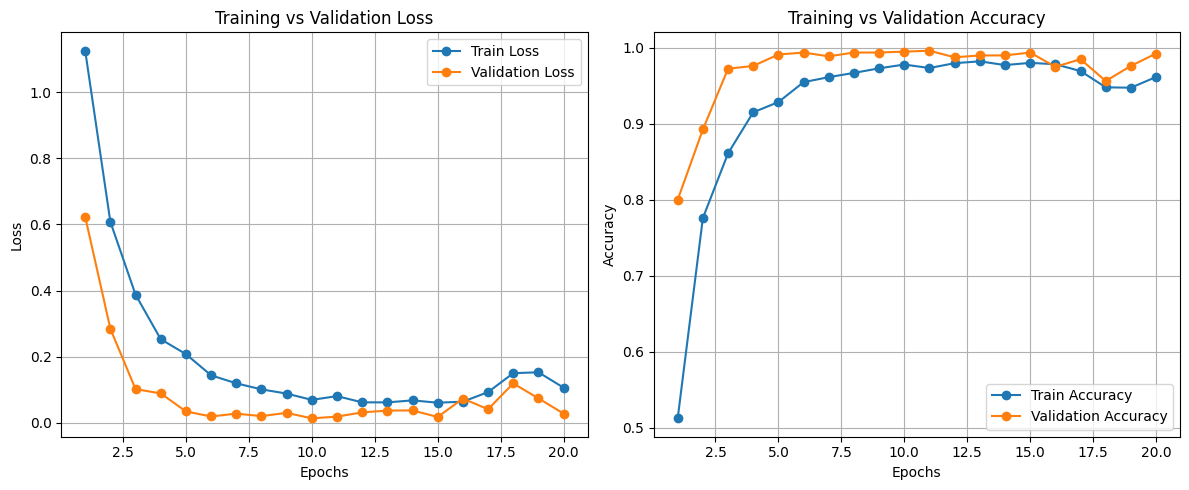

In [72]:
import matplotlib.pyplot as plt

num_epochs = len(train_losses)

plt.figure(figsize=(12, 5))

# LOSS GRAPH
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# ACCURACY GRAPH
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, marker='o', label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), val_accs, marker='o', label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [51]:
# 6) Final test evaluation
# ---------------------------
if os.path.exists(save_path):
    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    print("Loaded best model for final evaluation.")
else:
    print("No saved model found; evaluating current model.")

test_loss, test_acc, y_true, y_pred, y_prob = evaluate(test_loader)
print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Loaded best model for final evaluation.


C:\Users\Sathish\AppData\Local\Temp\ipykernel_14396\2108253163.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Test loss: 0.0219, Test acc: 0.9925
Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.9950    0.9900    0.9925       200
 Moderate Dementia     1.0000    0.9900    0.9950       200
      Non Demented     1.0000    0.9900    0.9950       200
Very Mild Dementia     0.9756    1.0000    0.9877       200

          accuracy                         0.9925       800
         macro avg     0.9926    0.9925    0.9925       800
      weighted avg     0.9926    0.9925    0.9925       800

Confusion Matrix:
 [[198   0   0   2]
 [  1 198   0   1]
 [  0   0 198   2]
 [  0   0   0 200]]


In [52]:
# multiclass AUC
try:
    from sklearn.preprocessing import label_binarize
    y_true_onehot = label_binarize(y_true, classes=list(range(len(class_names))))
    auc = roc_auc_score(y_true_onehot, y_prob, average='macro', multi_class='ovr')
    print("Macro AUC:", auc)
except Exception as e:
    print("Could not compute AUC:", e)

Could not compute AUC: index 4 is out of bounds for axis 1 with size 4


In [59]:
print("Unique y_true labels:", sorted(set(y_true)))
print("y_true_onehot shape:", y_true_onehot.shape)
print("y_prob shape:", y_prob.shape)


Unique y_true labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
y_true_onehot shape: (800, 4)
y_prob shape: (800, 10)


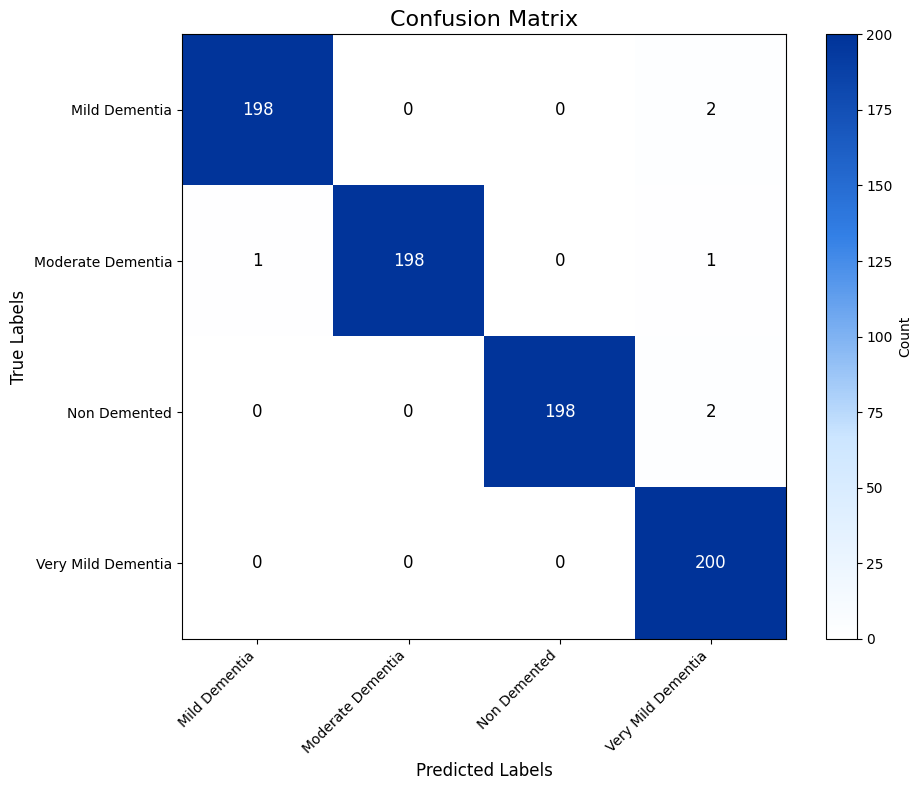

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Your confusion matrix (replace with yours)
cm = np.array([
    [198, 0, 0, 2],
    [1, 198, 0, 1],
    [0, 0, 198, 2],
    [0, 0, 0, 200]
])

class_names = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very Mild Dementia"]

# White → blue colormap
cmap = LinearSegmentedColormap.from_list(
    "white_blue",
    [(1, 1, 1), (0.8, 0.9, 1), (0.2, 0.5, 0.9), (0, 0.2, 0.6)],
    N=256
)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap=cmap, interpolation='nearest')

# Colorbar
cbar = plt.colorbar()
cbar.set_label('Count')

# Tick labels
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)

# Adding numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "black" if cm[i, j] < cm.max() / 2 else "white"
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color=text_color, fontsize=12)

plt.tight_layout()
plt.show()


In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 56 * 56, 128)  # adjust if img size differs
        self.fc2 = nn.Linear(128, 4)  # <-- 4 output classes

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)   # no softmax (PyTorch uses CrossEntropyLoss)
        return x

# Create model
model = MyCNN()
print(model)


MyCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=200704, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


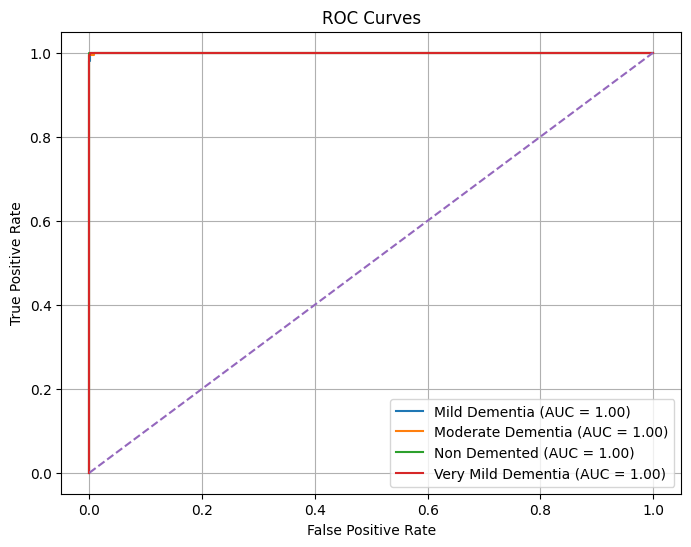

In [74]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

plt.figure(figsize=(8,6))

for c in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_prob[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[c]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


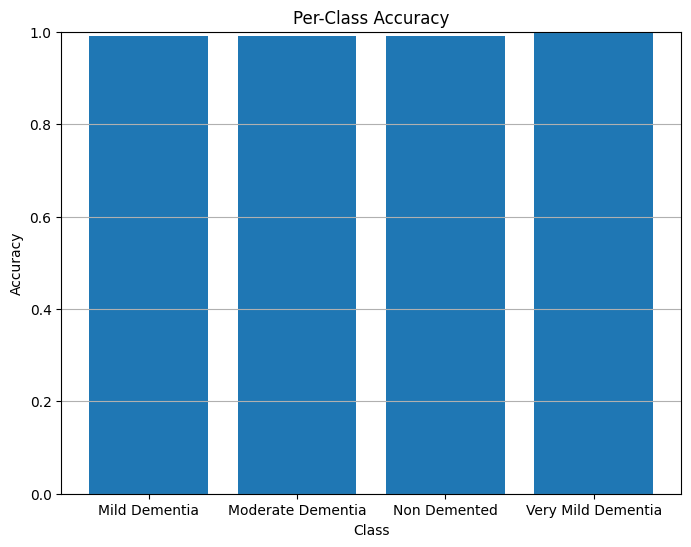

In [76]:
import numpy as np

class_correct = np.zeros(len(class_names))
class_total = np.zeros(len(class_names))

for t, p in zip(y_true, y_pred):
    class_total[t] += 1
    if t == p:
        class_correct[t] += 1

acc_per_class = class_correct / class_total

plt.figure(figsize=(8,6))
plt.bar(class_names, acc_per_class)
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.title("Per-Class Accuracy")
plt.ylim([0,1])
plt.grid(axis='y')
plt.show()


In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))


                    precision    recall  f1-score   support

     Mild Dementia       0.99      0.99      0.99       200
 Moderate Dementia       1.00      0.99      0.99       200
      Non Demented       1.00      0.99      0.99       200
Very Mild Dementia       0.98      1.00      0.99       200

          accuracy                           0.99       800
         macro avg       0.99      0.99      0.99       800
      weighted avg       0.99      0.99      0.99       800



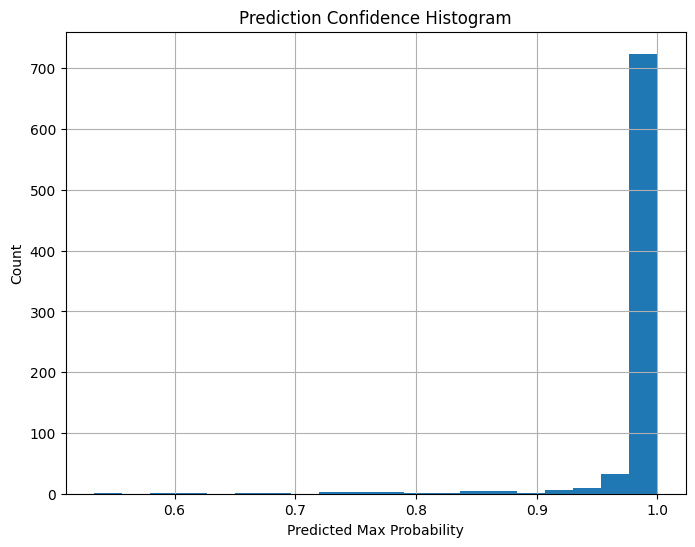

In [78]:
plt.figure(figsize=(8,6))
plt.hist(np.max(y_prob, axis=1), bins=20)
plt.xlabel("Predicted Max Probability")
plt.ylabel("Count")
plt.title("Prediction Confidence Histogram")
plt.grid(True)
plt.show()
